#                                          Outile of what I learned:
1. linear function/hypothesis function
2. cost function (MSE/squared error cost)
3. gradient descent ("batch" gradient descent)
4. multiple variables (features) linear regression
4. feature scaling (MinMax, mean normalization, z-score normalization) and choosing the right learning rate α
5. feature engineering
6. polynomial regression
7. scikit-learn for linear regression



**hypothesis function**   

In [16]:
import numpy as np
import matplotlib.pyplot as plt

predicted values (estimations): [295.77 497.95 700.13 902.31]
actual values (targets): [300. 500. 700. 900.]


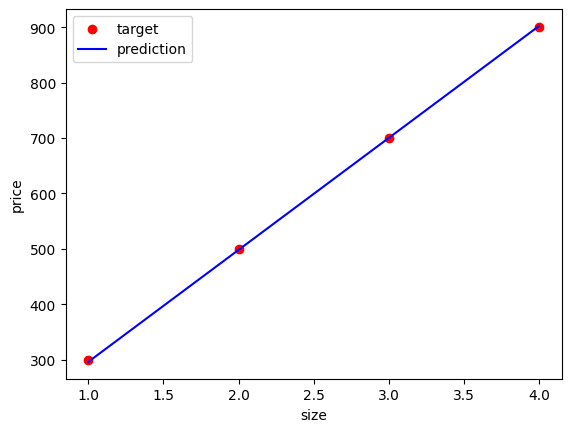

In [37]:
train_x = np.array([1, 2, 3, 4])
train_y = np.array([300.0, 500.0, 700.0, 900.0])

def hyp_func(x, w, b):
  m = x.shape[0]
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = x[i] * w + b
  return f_wb

w = 202.18
b = 93.59

f_wb = hyp_func(train_x, w, b)
print(f"predicted values (estimations): {f_wb}")
print(f"actual values (targets): {train_y}")
plt.scatter(train_x, train_y, c='r', label='target')
plt.plot(train_x, f_wb, c='b', label='prediction')
plt.xlabel("size")
plt.ylabel("price")
plt.legend()
plt.show()


**cost function**


In [30]:
def cost_func(x, y, w, b):
  m = x.shape[0]
  f_wb = hyp_func(x, w, b)
  cost = 0.
  for i in range(m):
    error = f_wb[i] - y[i]
    cost += error **2
  cost = cost / (2 * m)
  return cost

w = 200
b = 100
cost = cost_func(train_x, train_y, w, b)
print(f"cost function (w = {w} and b = {b}):   J(w,b) = {cost:.2f}")


cost function (w = 200 and b = 100):   J(w,b) = 0.00


**gradient descent**


In [4]:
# compute the partial derivative parts
def p_derivative(x, y, w, b):
  m = x.shape[0]
  f_wb = hyp_func(x, w, b)
  dj_dw, dj_db = 0., 0.
  for i in range(m):
    error = f_wb[i] - y[i]
    dj_dw += error * x[i]
    dj_db += error
  dj_dw = dj_dw / m
  dj_db = dj_db / m
  return dj_dw, dj_db

# gradient descent algorithm
def grad_desc(x, y, w, b, epoch, alpha):
  for i in range(epoch):
    dj_dw, dj_db = p_derivative(x, y, w, b)
    w_tmp = w - alpha * dj_dw
    b_tmp = b - alpha * dj_db
    w = w_tmp
    b = b_tmp
  return w, b

w, b = 0., 0.
alpha = 1.0e-2
epoch = 1000
w, b = grad_desc(train_x, train_y, w, b, epoch, alpha)
print("after gradient descent:")
print(f"w = {w:.2f}     , b = {b:.2f}")


after gradient descent:
w = 202.18     , b = 93.59


**multiple linear regression**


In [38]:
X = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
Y = np.array([460., 232., 178.])

# hypothesis function
def multi_hyp_func(x, w, b):
  m = x.shape[0]
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = np.dot(x[i], w) + b
  return f_wb

W = np.array([0.39, 18.75, -53, -26.])
B = 785.18
F_wb = multi_hyp_func(X, W, B)
print(f"predicted values: {F_wb}")
print(f"actual values: {Y.reshape(-1)}")


predicted values: [476.49 247.67 191.96]
actual values: [460. 232. 178.]


In [6]:
# cost function
def multi_cost_func(x, y, w, b):
  m = x.shape[0]
  f_wb = multi_hyp_func(x, w, b)
  cost = 0.00
  for i in range(m):
    error = f_wb[i] - y[i]
    cost += error**2
  cost = cost / (2 * m)
  return cost

COST = multi_cost_func(X, Y, W, B)
print(f"cost function (w = {W.tolist()} and b = {B}): J(w,b) = {COST:.2f}")


cost function (w = [0.39, 18.75, -53.0, -26.0] and b = 785.18): J(w,b) = 118.73


In [7]:
# compute the partial derivatives
def multi_p_derivative(x, y, w, b):
  m, n = x.shape[0], x.shape[1]
  f_wb = multi_hyp_func(x, w, b)
  dj_dw = np.zeros(n)
  dj_db = 0.00
  for i in range(m):
    error = f_wb[i] - y[i]
    for j in range(n):
      dj_dw[j] += error * x[i, j]
    dj_db += error
  dj_dw = dj_dw / m
  dj_db = dj_db / m
  return dj_dw, dj_db

# gradient descent algorithm
def multi_grad_desc(x, y, w, b, epoch, alpha):
  m = x.shape[0]
  for i in range(epoch):
    dj_dw, dj_db = multi_p_derivative(x, y, w, b)
    tmp_w = w - alpha * dj_dw
    tmp_b = b - alpha * dj_db
    w = tmp_w
    b = tmp_b
  return w, b

ALPHA = 1.0e-7
EPOCH = 4000
W_ = np.zeros_like(W)
B_ = 0.00
W_, B_ = multi_grad_desc(X, Y, W_, B_, EPOCH, ALPHA)
print("after gradient descent:")
print(f"w = {W_.tolist()}    , b = {B_:.2f}")


after gradient descent:
w = [0.20361219275547154, 0.003094209101893758, -0.008979179996869875, -0.05191766012373911]    , b = -0.00


**feature scaling**

we scale features so that all input variables are on a similar range, thus helping the gradient descent move more smoothly, and prevent one feature from dominating the learning process

if one feature is much larger than others, then the model pays more attention to that feature and causes gradient descent to take uneven steps

In [8]:
# Min-Max scaling   ->  [0, 1], doesn't change distribution shape, subtract by the min value and then divide by the range of the data
X = np.array([[11, 2],
              [3, 7],
              [0, 10],
              [11, 8]])
X_min = X.min(axis=0)   # [0, 2]
X_max = X.max(axis=0)   # [11, 10]
X_std = (X - X_min) / (X_max - X_min)
print("scaled array using min-max:")
print(X_std)


scaled array using min-max:
[[1.         0.        ]
 [0.27272727 0.625     ]
 [0.         1.        ]
 [1.         0.75      ]]


In [9]:
# mean normalization   -> [-1, 1], center the data around the mean 0, subtract by the mean value and then divide by the range of the data
x0 = np.array([[11, 2],
              [3, 7],
              [0, 10],
              [11, 8]])
x_mean = x0.mean(axis=0)
x_min = x0.min(axis=0)
x_max = x0.max(axis=0)
x_std = (x0 - x_mean) / x_max - x_min
print("scaled array using mean normalization:")
print(x_std)


scaled array using mean normalization:
[[ 0.43181818 -2.475     ]
 [-0.29545455 -1.975     ]
 [-0.56818182 -1.675     ]
 [ 0.43181818 -1.875     ]]


In [10]:
# z-score normalization (standardization)   -> mean=0 and std deviation=1, no fixed range, subtract by the mean value and divide by the standard deviation
d = np.array([11, 2, 3, 7, 0, 10, 11, 8])
d_mean = np.mean(d)
d_sdv = np.std(d)
d_std = (d - d_mean) / d_sdv
print("scaled array using z-score normalization:")
print(d_std.tolist())

scaled array using z-score normalization:
[1.116312611302876, -1.116312611302876, -0.8682431421244593, 0.12403473458920847, -1.61245154965971, 0.8682431421244593, 1.116312611302876, 0.3721042037676254]


**learning rate** $\alpha$ that is too high can cause the model/algorithm to diverge , while a rate that is too low can lead to slow convergence

try:
0.001 -> 0.003 -> 0.01 -> 0.03 -> 0.1 -> 0.3 -> 1 ...

pick $\alpha$ that decreases J(w,b) rapidly and consistently

read some examples from C1_W2_lab03



**feature engineering**


adding new features can help in cases where the original features might not fully describe the relationship between inputs and outputs, so it makes the relationships easier for the model to learn

use intuition to design new features by transforming or combining original features


read some examples from C1_W2_lab04



**polynomial regression**

adding nonlinear features, the linear model produces nonlinear shapes

if the polynomial degree is too high

read some examples from C1_W2_lab04



**scikit-learn for linear regression**

In [11]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler

In [12]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300, 500])
# create regression object
linear_model = LinearRegression()   # least squares linear regression
# perform regression: fit parameters to the input data (expects a 2-d matrix input)
linear_model.fit(x_train.reshape(-1,1), y_train)

LinearRegression()

In [13]:
# check parameters w and b
b = linear_model.intercept_
w = linear_model.coef_
print(f"w = {w}, b = {b:.2f}")

w = [200.], b = 100.00


In [14]:
# generate predictions
y_pred = linear_model.predict(x_train.reshape(-1,1))
print("predictions:", y_pred)
x_test = [[1200], [3000]]
print(f"prediction for 1200 sqft house: {linear_model.predict(x_test)[0]:.2f}")
print(f"prediction for 3000 sqft house: {linear_model.predict(x_test)[1]:.2f}")

predictions: [300. 500.]
prediction for 1200 sqft house: 240100.00
prediction for 3000 sqft house: 600100.00
